In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/final.csv")

--- Phase 1: Data Prep ---
 Train=2912  Test=733  Features=30
--- Phase 2: Tuning Parameters (15 searches) ---
 Best Params Found:
   subsample: 0.9
   reg_lambda: 1.0
   reg_alpha: 0.0
   num_leaves: 31
   min_child_samples: 20
   max_depth: 3
   learning_rate: 0.03
   colsample_bytree: 0.9
--- Phase 3: Forecast ---
 Test MAE: 0.469312


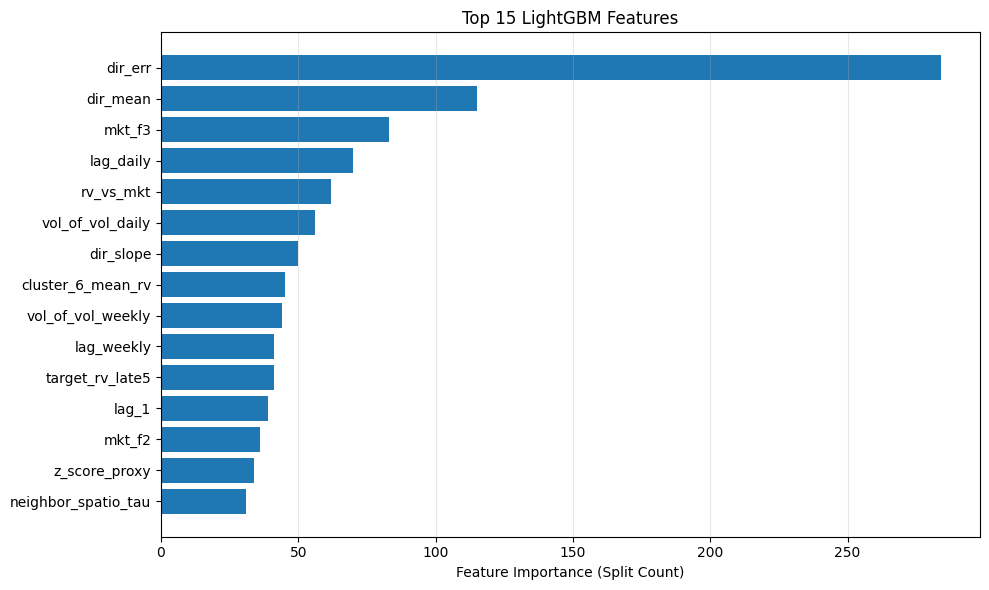


  Forecast Metrics — Tuned LightGBM
  Metric              Value
  --------------------------------------
  MAE                 +0.4693
  RMSE                +0.6022
  R²                  +0.4905
  MAPE (%)            +212.4482
  SMAPE (%)           +103.8172
  QLIKE               +5462061.8175
  Theil's U2          +0.4163
  MZ R²               +0.4911
  MZ Intercept        +0.0190
  MZ Slope            +0.9864
  Hit Rate (%)        +74.8977
  Dir R²              +0.6676
  Tail MAE 90         +0.9703
  Tail MAE 95         +1.1667
  Spearman r          +0.6832
  Pearson r           +0.7008
  Bias                +0.0193
  Bias (%)            +2.9611



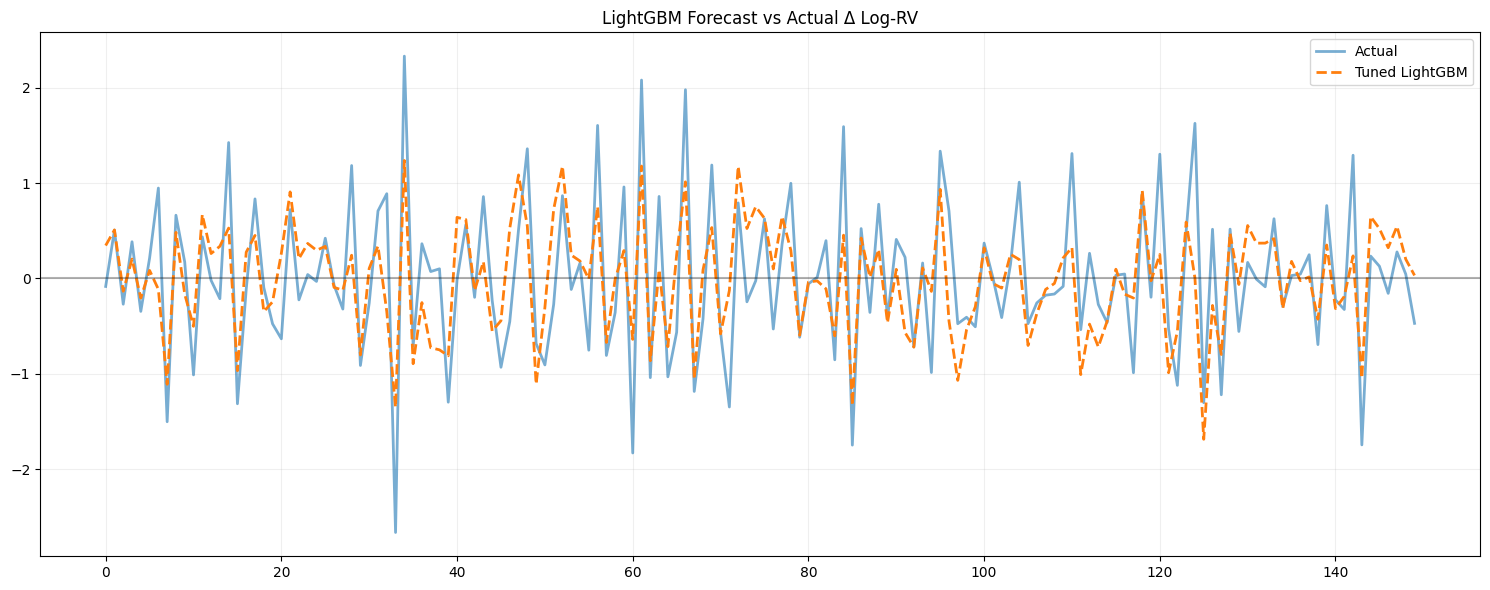

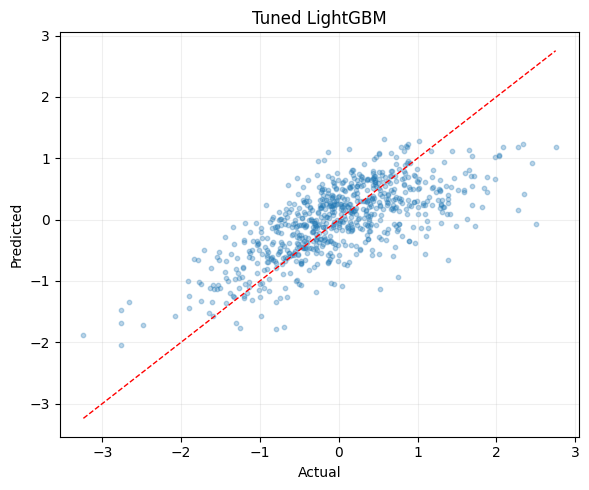

In [2]:
def evaluate_forecast(y_true, y_pred, label='Model'):
    eps = 1e-8
    err = y_true - y_pred

    mae   = np.mean(np.abs(err))
    rmse  = np.sqrt(np.mean(err**2))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs(err) / (np.abs(y_true) + eps)) * 100
    smape = np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    rv_true = np.clip(y_true, eps, None)
    rv_pred = np.clip(y_pred, eps, None)
    qlike   = np.mean(rv_true / rv_pred - np.log(rv_true / rv_pred) - 1)

    naive_err = y_true[1:] - y_true[:-1]
    theils_u2 = (np.sqrt(np.mean(err[1:]**2)) /
                 (np.sqrt(np.mean(naive_err**2)) + eps))

    X_mz                    = sm.add_constant(y_pred)
    mz                      = sm.OLS(y_true, X_mz).fit()
    mz_r2                   = mz.rsquared
    mz_intercept, mz_slope  = mz.params

    hit_rate     = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    correct_mask = np.sign(y_true) == np.sign(y_pred)
    dir_r2       = (r2_score(y_true[correct_mask], y_pred[correct_mask])
                    if correct_mask.sum() > 1 else np.nan)

    thresh_90, thresh_95 = np.quantile(np.abs(y_true), [0.90, 0.95])
    tail_mae_90 = np.mean(np.abs(err[np.abs(y_true) >= thresh_90]))
    tail_mae_95 = np.mean(np.abs(err[np.abs(y_true) >= thresh_95]))

    spearman_r, _ = spearmanr(y_true, y_pred)
    pearson_r,  _ = pearsonr(y_true,  y_pred)
    bias          = np.mean(err)
    bias_pct      = bias / (np.mean(np.abs(y_true)) + eps) * 100

    metrics = {
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE (%)': mape, 'SMAPE (%)': smape, 'QLIKE': qlike,
        "Theil's U2": theils_u2, 'MZ R²': mz_r2,
        'MZ Intercept': mz_intercept, 'MZ Slope': mz_slope,
        'Hit Rate (%)': hit_rate, 'Dir R²': dir_r2,
        'Tail MAE 90': tail_mae_90, 'Tail MAE 95': tail_mae_95,
        'Spearman r': spearman_r, 'Pearson r': pearson_r,
        'Bias': bias, 'Bias (%)': bias_pct,
    }

    col_w = 18
    print(f"\n{'='*42}\n  Forecast Metrics — {label}\n{'='*42}")
    print(f"  {'Metric':<{col_w}}  Value\n  {'-'*38}")
    for k, v in metrics.items():
        print(f"  {k:<{col_w}}  {v:+.4f}")
    print(f"{'='*42}\n")
    return metrics


# ================================================================================
# VISUALISATION
# ================================================================================

def plot_predictions_vs_actual(y_true, predictions_dict, n_samples=150, title=''):
    plt.figure(figsize=(15, 6))
    plt.plot(y_true[-n_samples:], label='Actual', color='#1f77b4', alpha=0.6, lw=2)
    for name, preds in predictions_dict.items():
        plt.plot(preds[-n_samples:], label=name,color='#ff7f0e', linestyle='--', lw=2)
    plt.axhline(0, color='black', alpha=0.3)
    plt.title(title or f'Forecast vs Actual (Last {n_samples} Time IDs)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_scatter_predictions(y_true, predictions_dict):
    n = len(predictions_dict)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, preds) in zip(axes, predictions_dict.items()):
        ax.scatter(y_true, preds, alpha=0.3, s=10, color='#1f77b4')
        lims = [min(y_true.min(), preds.min()), max(y_true.max(), preds.max())]
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(name)
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_lgbm_importance(model, feature_names, top_n=15):
    importance   = model.feature_importances_
    idx          = np.argsort(importance)[::-1][:top_n]
    top_features = [feature_names[i] for i in idx]
    top_scores   = importance[idx]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_features)), top_scores[::-1],
             align='center', color='#1f77b4')
    plt.yticks(range(len(top_features)), top_features[::-1])
    plt.xlabel('Feature Importance (Split Count)')
    plt.title(f'Top {top_n} LightGBM Features')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ================================================================================
# LGBM VOLATILITY FORECAST PIPELINE — COMPLETE, LEAKAGE-FREE (ENHANCED)
# ================================================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from numpy.linalg import lstsq
from scipy.stats import spearmanr, pearsonr

import warnings
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────────────────────
N_FACTORS    = 5
LAG_DAILY    = 5
LAG_WEEKLY   = 10
LAG_MONTHLY  = 20
N_CLUSTERS   = 7 # For Market Grouping


# ================================================================================
# HELPERS
# ================================================================================

def preprocess_and_downsample(df):
    time_order = df['time_id'].unique()
    time_rank  = {tid: i for i, tid in enumerate(time_order)}
    df = (df.assign(time_rank=df['time_id'].map(time_rank))
            .sort_values(['time_rank', 'seconds_in_bucket']))

    bucket_col = (df['seconds_in_bucket'] // BUCKET_SIZE).astype(np.int16)
    result = (df.assign(bucket_group=bucket_col)
                .groupby(['time_id', 'bucket_group'])
                .last()
                .reset_index())

    result = (result.assign(time_rank=result['time_id'].map(time_rank))
                    .sort_values(['time_rank', 'bucket_group'])
                    .drop(columns='time_rank')
                    .reset_index(drop=True))

    old_to_new = {tid: i for i, tid in enumerate(time_order)}
    result['time_id_orig'] = result['time_id']
    result['time_id']      = result['time_id'].map(old_to_new)
    return result


def compute_log_rv_matrix(df_raw):
    stock_cols = [c for c in df_raw.columns
                  if c not in ['time_id', 'seconds_in_bucket',
                                 'time_id_orig']]

    def get_rv(group):
        log_prices = np.log(group[stock_cols].replace(0, np.nan)).ffill()
        log_ret    = log_prices.diff().dropna()
        rv         = np.sqrt((log_ret ** 2).sum() / len(log_ret))  # ← per-tick
        return np.log(rv + 1e-11)

    full_rv = df_raw.groupby('time_id')[stock_cols].apply(get_rv)
    return full_rv, stock_cols


def get_target_bucket_features(df_down, target_stock):
    """
    Extracts time-window and lstsq directional stats per time_id for the target stock.
    """
    records = []
    for tid, group in df_down.groupby('time_id'):
        group  = group.sort_values('seconds_in_bucket')
        prices = group[target_stock].replace(0, np.nan).ffill().values
        if len(prices) < 2:
            continue

        log_ret = np.diff(np.log(prices))

        # ── 1. Time Windows (Late Volatility) ──
        # rv for the last 5 buckets (e.g. last 300s) and last 3 buckets (180s)
        seconds = group['seconds_in_bucket'].values
        late_5_mask = seconds >= (seconds[-1] - 300)   # last 300 seconds
        late_3_mask = seconds >= (seconds[-1] - 180)   # last 180 seconds

        rv_late_5 = np.log(np.sqrt(np.sum(log_ret[late_5_mask[1:]]**2)) + 1e-11)
        rv_late_3 = np.log(np.sqrt(np.sum(log_ret[late_3_mask[1:]]**2)) + 1e-11)

        # ── 2. Directional Stats (via lstsq) ──
        bucket_vols = np.abs(log_ret)
        if len(bucket_vols) > 2:
            mat = np.vstack([np.ones(len(bucket_vols)), np.arange(len(bucket_vols))]).T
            coefs, err, _, _ = lstsq(mat, bucket_vols, rcond=None)
            err_val = err[0] if err.size > 0 else 0.0
            mean_val = coefs[0] + (len(bucket_vols) / 2) * coefs[1]
            slope_val = coefs[1]
        else:
            mean_val, slope_val, err_val = np.nan, np.nan, np.nan

        records.append({
            'time_id': tid,
            'target_rv_late5': rv_late_5,
            'target_rv_late3': rv_late_3,
            'dir_mean': mean_val,
            'dir_slope': slope_val,
            'dir_err': err_val
        })

    return pd.DataFrame(records).set_index('time_id')


def get_mean_reversion_features(df_features):
    m_df = pd.DataFrame(index=df_features.index)

    rolling_max           = df_features['target_rv'].rolling(window=10).max()
    m_df['dist_to_peak']  = df_features['target_rv'] - rolling_max
    m_df['rv_momentum']   = df_features['target_rv'].diff()

    rolling_std           = df_features['target_rv'].rolling(20).std().fillna(1.0)
    m_df['z_score_proxy'] = (
        (df_features['target_rv'] - df_features['lag_daily'])
        / (rolling_std + 1e-6)
    )
    return m_df


def get_static_features(full_rv, bucket_feats, fitted_params=None):
    is_fit = fitted_params is None

    rv_matrix    = full_rv.replace([np.inf, -np.inf], np.nan).dropna()
    target_stock = full_rv.columns[0]
    features     = pd.DataFrame(index=rv_matrix.index)
    features['target_rv'] = rv_matrix[target_stock]

    # Cross-sectional
    features['mkt_mean_rv']   = rv_matrix.mean(axis=1)
    features['mkt_median_rv'] = rv_matrix.median(axis=1)
    features['rv_vs_mkt']     = features['target_rv'] - features['mkt_mean_rv']

    # ── NEW: Market-Level Clustering (K-Means) ────────────────────────────────
    if is_fit:
        # Cluster stocks based on their volatility patterns across time
        kmeans = KMeans(n_clusters=min(N_CLUSTERS, len(rv_matrix.columns)), random_state=42, n_init=10)
        kmeans.fit(rv_matrix.T)
        cluster_labels = kmeans.labels_
    else:
        kmeans = fitted_params['kmeans']
        cluster_labels = fitted_params['cluster_labels']

    cluster_features = {}
    for c in range(kmeans.n_clusters):
        c_stocks = rv_matrix.columns[cluster_labels == c]
        if len(c_stocks) > 0:
            cluster_features[f'cluster_{c}_mean_rv'] = rv_matrix[c_stocks].mean(axis=1)
        else:
            cluster_features[f'cluster_{c}_mean_rv'] = 0.0

    cluster_df = pd.DataFrame(cluster_features, index=rv_matrix.index)

    # ── 1. StandardScaler + PCA ───────────────────────────────────────────────
    if is_fit:
        scaler      = StandardScaler()
        scaled_rv   = scaler.fit_transform(rv_matrix)
        pca         = PCA(n_components=N_FACTORS)
        mkt_factors = pca.fit_transform(scaled_rv)
    else:
        scaler      = fitted_params['scaler']
        pca         = fitted_params['pca']
        scaled_rv   = scaler.transform(rv_matrix)
        mkt_factors = pca.transform(scaled_rv)

    mkt_df = pd.DataFrame(
        mkt_factors, index=rv_matrix.index,
        columns=[f'mkt_f{i}' for i in range(N_FACTORS)]
    )

    # ── 2. KNN: Stock Similarity ──────────────────────────────────────────────
    if is_fit:
        nn_stock = NearestNeighbors(n_neighbors=min(5, len(rv_matrix.columns)), metric='manhattan').fit(rv_matrix.T)
        _, s_idx               = nn_stock.kneighbors(rv_matrix.T)
        similar_stocks_indices = s_idx[0, 1:]
    else:
        similar_stocks_indices = fitted_params['similar_stocks_indices']

    # ── 3. KNN: Time Similarity ───────────────────────────────────────────────
    if is_fit:
        nn_time = NearestNeighbors(n_neighbors=6, metric='manhattan').fit(mkt_factors)
    else:
        nn_time = fitted_params['nn_time']

    _, t_idx = nn_time.kneighbors(mkt_factors)

    # ── 4. Spatio-Temporal Feature ("Tau") ────────────────────────────────────
    spatio_temp_feat = []
    source_rv        = rv_matrix if is_fit else fitted_params['rv_matrix']

    for row_idx in range(len(t_idx)):
        neighbors = t_idx[row_idx]
        past = [i for i in neighbors if i < row_idx] if is_fit else list(neighbors)

        if not past:
            spatio_temp_feat.append(np.nan)
        else:
            val = source_rv.iloc[past[:5], similar_stocks_indices].values.mean()
            spatio_temp_feat.append(val)

    t_feats = pd.DataFrame(index=rv_matrix.index)
    t_feats['neighbor_spatio_tau'] = spatio_temp_feat

    # ── 5. Lags & Vol-of-Vol ──────────────────────────────────────────────────
    features['lag_1']             = features['target_rv'].shift(1)
    features['lag_daily']         = features['target_rv'].rolling(LAG_DAILY).mean()
    features['lag_weekly']        = features['target_rv'].rolling(LAG_WEEKLY).mean()
    features['lag_monthly']       = features['target_rv'].rolling(LAG_MONTHLY).mean()
    features['vol_of_vol_daily']  = features['target_rv'].rolling(LAG_DAILY).std()
    features['vol_of_vol_weekly'] = features['target_rv'].rolling(LAG_WEEKLY).std()

    # ── 6. Combine All ────────────────────────────────────────────────────────
    reversion_df   = get_mean_reversion_features(features)

    # Merge existing + K-Means + lstsq Bucket Features
    final_features = features.join([mkt_df, t_feats, reversion_df, cluster_df, bucket_feats])

    final_features['neighbor_spatio_tau'] = final_features['neighbor_spatio_tau'].ffill()
    final_features = final_features.dropna()

    if is_fit:
        params = dict(scaler=scaler, pca=pca,
                      similar_stocks_indices=similar_stocks_indices,
                      nn_time=nn_time, rv_matrix=rv_matrix,
                      kmeans=kmeans, cluster_labels=cluster_labels)
        return final_features, params

    return final_features, None


# ================================================================================
# PIPELINE EXECUTION
# ================================================================================

def run_tuned_lgbm_pipeline(df, train_pct=0.8, n_iter_search=15):

    print("--- Phase 1: Data Prep ---")

    # Sort raw data — no downsampling, no bucket filter
    time_order = df['time_id'].unique()
    time_rank  = {tid: i for i, tid in enumerate(time_order)}
    df_raw = (df.assign(time_rank=df['time_id'].map(time_rank))
                .sort_values(['time_rank', 'seconds_in_bucket'])
                .drop(columns='time_rank')
                .reset_index(drop=True))

    full_rv, stock_cols = compute_log_rv_matrix(df_raw)

    target_stock = stock_cols[0]
    bucket_feats = get_target_bucket_features(df_raw, target_stock)  # raw df

    # Everything below this line is UNCHANGED
    split_idx  = int(len(full_rv) * train_pct)

    full_rv_tr = full_rv.iloc[:split_idx].copy()
    full_rv_te = full_rv.iloc[split_idx - LAG_MONTHLY:].copy()

    # Align bucket features with splits
    b_feats_tr = bucket_feats.reindex(full_rv_tr.index)
    b_feats_te = bucket_feats.reindex(full_rv_te.index)

    # get_static_features: fit K-Means/PCA/Scaler on train, transform test
    static_tr, sf_params = get_static_features(full_rv_tr, b_feats_tr)
    static_te, _         = get_static_features(full_rv_te, b_feats_te, fitted_params=sf_params)

    # Target: RV(t+1) - RV(t)
    def make_xy(static_df):
        y = (static_df['target_rv'].shift(-1) - static_df['target_rv']).dropna()
        X = static_df.drop(columns=['target_rv']).iloc[:-1]
        return X, y

    X_tr, y_tr = make_xy(static_tr)
    X_te, y_te = make_xy(static_te)

    print(f" Train={len(y_tr)}  Test={len(y_te)}  Features={X_tr.shape[1]}")

    print(f"--- Phase 2: Tuning Parameters ({n_iter_search} searches) ---")
    tscv = TimeSeriesSplit(n_splits=3)

    param_grid = {
        'learning_rate':     [0.01, 0.03, 0.05, 0.1],
        'num_leaves':        [15, 31, 63, 127],
        'max_depth':         [3, 5, 7, -1],
        'min_child_samples': [10, 20, 50, 100],
        'subsample':         [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
        'reg_alpha':         [0.0, 0.1, 0.5, 1.0],
        'reg_lambda':        [0.0, 0.1, 1.0, 5.0],
    }

    base_lgb = lgb.LGBMRegressor(
        objective='huber', random_state=42, n_estimators=200, verbose=-1
    )

    search = RandomizedSearchCV(
        estimator=base_lgb,
        param_distributions=param_grid,
        n_iter=n_iter_search,
        scoring='neg_mean_absolute_error',
        cv=tscv,
        random_state=42,
        n_jobs=-1,
    )

    search.fit(X_tr, y_tr)
    best_model = search.best_estimator_

    print(" Best Params Found:")
    for k, v in search.best_params_.items():
        print(f"   {k}: {v}")

    print("--- Phase 3: Forecast ---")
    y_pred = best_model.predict(X_te)
    mae    = np.mean(np.abs(y_te - y_pred))
    print(f" Test MAE: {mae:.6f}")

    return y_te.values, y_pred, best_model, X_tr.columns

# ================================================================================
# MAIN
# ================================================================================

if __name__ == "__main__":

    y_true_lgb, y_pred_lgb, best_lgb_model, feature_cols = run_tuned_lgbm_pipeline(
        df, train_pct=0.8, n_iter_search=15
    )

    plot_lgbm_importance(best_lgb_model, feature_cols)

    evaluate_forecast(y_true_lgb, y_pred_lgb, label='Tuned LightGBM')

    lgbm_preds = {'Tuned LightGBM': y_pred_lgb}

    plot_predictions_vs_actual(
        y_true=y_true_lgb,
        predictions_dict=lgbm_preds,
        n_samples=150,
        title="LightGBM Forecast vs Actual Δ Log-RV"
    )

    plot_scatter_predictions(
        y_true=y_true_lgb,
        predictions_dict=lgbm_preds
    )